# CT Slice Localization — Deep Learning Regression
## Dense Neural Network (DNN) + 1D Convolutional Neural Network (CNN) with Bayesian Hyperparameter Optimization

This notebook extends the XGBoost baseline from the original project by implementing two neural architectures:

1. **Deep Neural Network (DNN)** — Fully connected layers with BatchNorm and Dropout for regularization.
2. **1D CNN** — Treats the 384 HOG features as a 1D temporal/spatial sequence and extracts local patterns via convolution.
3. **Hybrid DNN + 1D CNN** — A parallel architecture that fuses both representations for stronger predictions.

Hyperparameter search is performed using **Optuna** with a **Tree-structured Parzen Estimator (TPE)** sampler — the standard Bayesian Optimization engine.

### Why neural networks for this task?
- The 384 HOG features are spatially ordered (neighboring features describe adjacent image regions). CNNs can exploit that local structure.
- DNNs can learn non-linear interactions between features that tree models sometimes miss.
- The hybrid fuses both strategies for complementary feature extraction.

## 1. Install Dependencies

In [1]:
!pip install optuna torch scikit-learn pandas numpy matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import optuna
from optuna.samplers import TPESampler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## 3. Load and Preprocess Data

We replicate the same data preparation pipeline from the baseline notebook:
- Patient-level Group Split (no data leakage)
- Feature filtering (remove zero-variance and highly correlated features)
- StandardScaler (critical for neural networks)

In [3]:
# ── Load Data ──────────────────────────────────────────────────────────────────
# Update path as needed (Google Drive or local)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/slice localization/slice_localization_data.csv'

df = pd.read_csv(file_path)

print(f'Dataset shape: {df.shape}')
print(f'Unique patients: {df["patientId"].nunique()}')
df.head(3)

Dataset shape: (53500, 386)
Unique patients: 97


,patientId,value0,value1,value2,value3,value4,value5,value6,value7,value8,...,value375,value376,value377,value378,value379,value380,value381,value382,value383,target
0,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.980381,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,21.803851
1,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.977008,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,21.745726
2,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.977008,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,21.687600


In [5]:
# ── Feature Engineering ────────────────────────────────────────────────────────
# Identify value columns (HOG features)
value_cols = [c for c in df.columns if c.startswith('value')]
print(f'Total HOG feature columns: {len(value_cols)}')

# 1. Drop zero-variance features
std_vals = df[value_cols].std()
constant_features = std_vals[std_vals < 1e-4].index.tolist()
print(f'Constant features removed: {len(constant_features)}')

# 2. Drop highly correlated features (|r| > 0.95)
remaining = [c for c in value_cols if c not in constant_features]
corr_matrix = df[remaining].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_features = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'Redundant features removed: {len(redundant_features)}')

# 3. Drop features with low correlation to target
remaining2 = [c for c in remaining if c not in redundant_features]
target_corr = df[remaining2].corrwith(df['target']).abs()
irrelevant_features = target_corr[target_corr < 0.05].index.tolist()
print(f'Irrelevant features (low target corr) removed: {len(irrelevant_features)}')

features_to_drop = list(set(constant_features + redundant_features + irrelevant_features))
df_filtered = df.drop(columns=features_to_drop)

FEATURE_COLS = [c for c in df_filtered.columns if c.startswith('value')]
print(f'\nFinal feature count: {len(FEATURE_COLS)}')

Total HOG feature columns: 384
Constant features removed: 5
Redundant features removed: 29
Irrelevant features (low target corr) removed: 76

Final feature count: 274


In [6]:
# ── Group-Based Train / Test Split ─────────────────────────────────────────────
X = df_filtered[FEATURE_COLS].values
y = df_filtered['target'].values
groups = df_filtered['patientId'].values

gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Training slices : {len(X_train_raw)}')
print(f'Testing  slices : {len(X_test_raw)}')
print(f'Train patients  : {len(np.unique(groups[train_idx]))}')
print(f'Test  patients  : {len(np.unique(groups[test_idx]))}')

Training slices : 43338
Testing  slices : 10162
Train patients  : 77
Test  patients  : 20


In [7]:
X_train = X_train_raw.astype(np.float32)
X_test  = X_test_raw.astype(np.float32)

y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)

INPUT_DIM = X_train.shape[1]
print(f'Input dimension after preprocessing: {INPUT_DIM}')

Input dimension after preprocessing: 274


## 4. PyTorch Dataset & DataLoader

In [8]:
class SliceDataset(Dataset):
    """Custom PyTorch Dataset for CT slice regression."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N, 1)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(X_tr, y_tr, X_te, y_te, batch_size: int = 256):
    train_ds = SliceDataset(X_tr, y_tr)
    test_ds  = SliceDataset(X_te, y_te)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, test_loader


print('Dataset helpers defined.')

Dataset helpers defined.


## 5. Model Architectures

### Architecture A — Deep Neural Network (DNN)
Stacked fully-connected layers with BatchNorm and Dropout. Good at learning global feature interactions.

### Architecture B — 1D Convolutional Neural Network (1D CNN)
Treats the sorted HOG features as a 1D sequence. Convolution kernels extract local patterns from neighboring features, similar to how a CNN extracts edges in images.

### Architecture C — Hybrid (Parallel DNN + 1D CNN)
Both branches process the same input in parallel. Their embeddings are concatenated and passed through a shared regression head. This lets the model exploit both local and global patterns simultaneously.

In [9]:
# ── Architecture A: Deep Neural Network ───────────────────────────────────────
class DNN(nn.Module):
    """
    Deep Neural Network for regression.

    Parameters
    ----------
    input_dim   : number of input features
    hidden_dims : list of hidden layer widths
    dropout_p   : dropout probability (applied after each hidden layer)
    """

    def __init__(self, input_dim: int, hidden_dims: list, dropout_p: float = 0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(p=dropout_p),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))   # regression head
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ── Architecture B: 1D CNN ─────────────────────────────────────────────────────
class CNN1D(nn.Module):
    """
    1D Convolutional Neural Network for regression.

    The feature vector is reshaped to (batch, 1, input_dim) so each conv
    kernel slides over the feature sequence and captures local correlations.

    Parameters
    ----------
    input_dim      : number of input features
    num_filters    : number of convolutional filters per layer
    kernel_size    : size of each 1D convolution window
    num_conv_layers: number of conv blocks
    fc_dims        : list of fully-connected layer widths after global pooling
    dropout_p      : dropout probability
    """

    def __init__(
        self,
        input_dim: int,
        num_filters: int = 64,
        kernel_size: int = 5,
        num_conv_layers: int = 3,
        fc_dims: list = [128, 64],
        dropout_p: float = 0.3,
    ):
        super().__init__()
        self.input_dim = input_dim

        # ── Convolutional blocks ────────────────────────────────────────────
        conv_blocks = []
        in_channels = 1
        for i in range(num_conv_layers):
            out_channels = num_filters * (2 ** min(i, 2))  # 64 → 128 → 256 → 256 ...
            conv_blocks += [
                nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2),
                nn.BatchNorm1d(out_channels),
                nn.GELU(),
                nn.MaxPool1d(kernel_size=2, stride=2),
                nn.Dropout1d(p=dropout_p / 2),
            ]
            in_channels = out_channels
        self.conv_net = nn.Sequential(*conv_blocks)

        # ── Global Average Pooling ──────────────────────────────────────────
        self.gap = nn.AdaptiveAvgPool1d(1)   # → (batch, channels, 1)

        # ── Fully-connected head ────────────────────────────────────────────
        fc_layers = []
        prev = in_channels
        for fc in fc_dims:
            fc_layers += [
                nn.Linear(prev, fc),
                nn.BatchNorm1d(fc),
                nn.GELU(),
                nn.Dropout(p=dropout_p),
            ]
            prev = fc
        fc_layers.append(nn.Linear(prev, 1))
        self.fc_net = nn.Sequential(*fc_layers)

    def forward(self, x):
        # x: (batch, features)  → (batch, 1, features)
        x = x.unsqueeze(1)
        x = self.conv_net(x)     # (batch, channels, L)
        x = self.gap(x)          # (batch, channels, 1)
        x = x.squeeze(-1)        # (batch, channels)
        return self.fc_net(x)


# ── Architecture C: Hybrid DNN + 1D CNN ───────────────────────────────────────
class HybridModel(nn.Module):
    """
    Parallel DNN + 1D CNN fusion model.

    Both branches process the input in parallel. Their final embeddings are
    concatenated and passed through a shared regression head.
    """

    def __init__(
        self,
        input_dim: int,
        # DNN branch params
        dnn_hidden_dims: list = [512, 256, 128],
        # CNN branch params
        cnn_num_filters: int = 64,
        cnn_kernel_size: int = 5,
        cnn_num_conv_layers: int = 3,
        cnn_fc_dims: list = [128],
        # Shared params
        dropout_p: float = 0.3,
        fusion_dim: int = 64,
    ):
        super().__init__()

        # ── DNN branch (without final output layer) ─────────────────────────
        dnn_layers = []
        prev = input_dim
        for h in dnn_hidden_dims:
            dnn_layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(p=dropout_p),
            ]
            prev = h
        self.dnn_branch = nn.Sequential(*dnn_layers)
        dnn_out_dim = dnn_hidden_dims[-1]

        # ── CNN branch (without final FC output layer) ──────────────────────
        conv_blocks = []
        in_ch = 1
        for i in range(cnn_num_conv_layers):
            out_ch = cnn_num_filters * (2 ** min(i, 2))
            conv_blocks += [
                nn.Conv1d(in_ch, out_ch, kernel_size=cnn_kernel_size, padding=cnn_kernel_size // 2),
                nn.BatchNorm1d(out_ch),
                nn.GELU(),
                nn.MaxPool1d(2, 2),
                nn.Dropout1d(p=dropout_p / 2),
            ]
            in_ch = out_ch
        self.cnn_conv = nn.Sequential(*conv_blocks)
        self.cnn_gap  = nn.AdaptiveAvgPool1d(1)

        cnn_fc_layers = []
        prev = in_ch
        for fc in cnn_fc_dims:
            cnn_fc_layers += [
                nn.Linear(prev, fc),
                nn.BatchNorm1d(fc),
                nn.GELU(),
                nn.Dropout(p=dropout_p),
            ]
            prev = fc
        self.cnn_fc = nn.Sequential(*cnn_fc_layers)
        cnn_out_dim = cnn_fc_dims[-1]

        # ── Fusion head ─────────────────────────────────────────────────────
        fused_dim = dnn_out_dim + cnn_out_dim
        self.fusion_head = nn.Sequential(
            nn.Linear(fused_dim, fusion_dim),
            nn.BatchNorm1d(fusion_dim),
            nn.GELU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(fusion_dim, 1),
        )

    def forward(self, x):
        # DNN branch
        dnn_out = self.dnn_branch(x)         # (batch, dnn_out_dim)

        # CNN branch
        cnn_x = x.unsqueeze(1)               # (batch, 1, features)
        cnn_x = self.cnn_conv(cnn_x)
        cnn_x = self.cnn_gap(cnn_x).squeeze(-1)
        cnn_out = self.cnn_fc(cnn_x)         # (batch, cnn_out_dim)

        # Fusion
        fused = torch.cat([dnn_out, cnn_out], dim=1)
        return self.fusion_head(fused)


# Quick sanity check
dummy = torch.randn(8, INPUT_DIM)
print('DNN output shape    :', DNN(INPUT_DIM, [512, 256, 128])(dummy).shape)
print('CNN1D output shape  :', CNN1D(INPUT_DIM)(dummy).shape)
print('Hybrid output shape :', HybridModel(INPUT_DIM)(dummy).shape)

DNN output shape    : torch.Size([8, 1])
CNN1D output shape  : torch.Size([8, 1])
Hybrid output shape : torch.Size([8, 1])


## 6. Training & Evaluation Utilities

In [10]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy().flatten()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy().flatten())
    preds   = np.array(all_preds)
    targets = np.array(all_targets)
    mae  = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2   = r2_score(targets, preds)
    return mae, rmse, r2, preds, targets


def train_model(
    model,
    train_loader,
    val_loader,
    *,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    epochs: int = 15,
    patience: int = 15,
    device=DEVICE,
    verbose: bool = True,
):
    """
    Full training loop with:
    - Huber loss (robust to outliers — better than MSE for this dataset)
    - AdamW optimizer
    - OneCycleLR scheduler
    - Early stopping
    """
    model.to(device)
    criterion = nn.HuberLoss(delta=5.0)   # delta tuned for target range 0-100
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.1,
        anneal_strategy='cos',
    )

    best_val_mae = float('inf')
    best_state   = None
    patience_ctr = 0
    history = {'train_loss': [], 'val_mae': [], 'val_rmse': [], 'val_r2': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        scheduler.step()  # NOTE: OneCycleLR steps per batch, not epoch; see note below
        val_mae, val_rmse, val_r2, _, _ = evaluate(model, val_loader, device)

        history['train_loss'].append(train_loss)
        history['val_mae'].append(val_mae)
        history['val_rmse'].append(val_rmse)
        history['val_r2'].append(val_r2)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f'  Epoch {epoch:>4d}/{epochs} | '
                  f'Train Loss: {train_loss:.4f} | '
                  f'Val MAE: {val_mae:.4f} | '
                  f'Val RMSE: {val_rmse:.4f} | '
                  f'R²: {val_r2:.4f}')

        if patience_ctr >= patience:
            if verbose:
                print(f'  Early stopping at epoch {epoch}. Best Val MAE: {best_val_mae:.4f}')
            break

    model.load_state_dict(best_state)
    return model, history


print('Training utilities defined.')

Training utilities defined.


## 7. Bayesian Hyperparameter Optimization with Optuna

Optuna's **TPE sampler** is a Bayesian Optimization strategy. Instead of exhaustively searching the grid or random sampling, it builds a probabilistic model of the objective function:

- After each trial, it learns *which* hyperparameter regions produced good (low MAE) results.
- It then **samples more densely from promising regions** and less from poor ones.
- This is orders of magnitude more efficient than grid search for large search spaces.

### Search Space
We search over:
- Architecture type (DNN / CNN / Hybrid)
- Layer widths and depth
- Learning rate, weight decay
- Dropout probability
- Batch size
- CNN-specific: kernel size, number of filters, number of conv layers

In [11]:
# ── Optuna Objective Function ──────────────────────────────────────────────────
def build_model_from_trial(trial, input_dim: int):
    """Construct a model from Optuna hyperparameter suggestions."""
    arch = trial.suggest_categorical('arch', ['DNN', 'CNN1D', 'Hybrid'])
    dropout_p = trial.suggest_float('dropout_p', 0.35, 0.5)

    if arch == 'DNN':
        n_layers = trial.suggest_int('dnn_n_layers', 2, 5)
        hidden_dims = [
            trial.suggest_categorical(f'dnn_h{i}', [32, 64,128, 256])
            for i in range(n_layers)
        ]
        model = DNN(input_dim, hidden_dims, dropout_p)

    elif arch == 'CNN1D':
        num_filters    = trial.suggest_categorical('cnn_filters', [32, 64, 128])
        kernel_size    = trial.suggest_categorical('cnn_kernel', [3, 5, 7, 11])
        num_conv_layers= trial.suggest_int('cnn_conv_layers', 2, 4)
        n_fc           = trial.suggest_int('cnn_n_fc', 1, 3)
        fc_dims        = [
            trial.suggest_categorical(f'cnn_fc{i}', [64, 128, 256])
            for i in range(n_fc)
        ]
        model = CNN1D(input_dim, num_filters, kernel_size, num_conv_layers, fc_dims, dropout_p)

    else:  # Hybrid
        dnn_n_layers = trial.suggest_int('hyb_dnn_n_layers', 2, 4)
        dnn_hidden   = [
            trial.suggest_categorical(f'hyb_dnn_h{i}', [128, 256, 512])
            for i in range(dnn_n_layers)
        ]
        cnn_filters  = trial.suggest_categorical('hyb_cnn_filters', [128,256])
        cnn_kernel   = trial.suggest_categorical('hyb_cnn_kernel', [5, 7,9])
        cnn_conv_l   = trial.suggest_int('hyb_cnn_conv_l', 2, 3)
        cnn_fc_dim   = trial.suggest_categorical('hyb_cnn_fc', [64, 128])
        fusion_dim   = trial.suggest_categorical('hyb_fusion', [32, 64, 128])
        model = HybridModel(
            input_dim,
            dnn_hidden_dims   = dnn_hidden,
            cnn_num_filters   = cnn_filters,
            cnn_kernel_size   = cnn_kernel,
            cnn_num_conv_layers = cnn_conv_l,
            cnn_fc_dims       = [cnn_fc_dim],
            dropout_p         = dropout_p,
            fusion_dim        = fusion_dim,
        )

    return model


def objective(trial):
    """Optuna objective — minimize validation MAE."""
    # ── Hyperparameters ────────────────────────────────────────────────────
    lr           = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-4, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [32, 64, 128])
    epochs       = trial.suggest_int('epochs', 25, 35)

    # ── Build model ────────────────────────────────────────────────────────
    model = build_model_from_trial(trial, INPUT_DIM)

    # ── Data loaders ───────────────────────────────────────────────────────
    train_loader, val_loader = make_loaders(X_train, y_train, X_test, y_test, batch_size)

    # ── Train (no verbose during search) ──────────────────────────────────
    model, history = train_model(
        model, train_loader, val_loader,
        lr=lr, weight_decay=weight_decay,
        epochs=epochs, patience=5,
        device=DEVICE, verbose=False,
    )

    # ── Evaluate ───────────────────────────────────────────────────────────
    val_mae, _, _, _, _ = evaluate(model, val_loader, DEVICE)
    return val_mae


print('Optuna objective function defined.')

Optuna objective function defined.


In [12]:
# ── Run Bayesian Optimization ──────────────────────────────────────────────────
# n_trials=50 is a good starting point; increase to 100+ for better coverage.
# MedianPruner stops unpromising trials early for faster search.

print('Starting Bayesian Optimization (Optuna TPE)...')
print('This will take several minutes. Increase n_trials for a more thorough search.')

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED, n_startup_trials=10),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    study_name='slice_localization_nn',
)

t0 = time.time()
study.optimize(objective, n_trials=15, show_progress_bar=True)
elapsed = time.time() - t0

print(f'\n--- Bayesian Optimization Complete ({elapsed/60:.1f} min) ---')
print(f'Best Trial : #{study.best_trial.number}')
print(f'Best MAE   : {study.best_value:.4f}')
print('Best Params:')
for k, v in study.best_params.items():
    print(f'  {k:30s}: {v}')

Starting Bayesian Optimization (Optuna TPE)...
This will take several minutes. Increase n_trials for a more thorough search.


  0%|          | 0/15 [00:00<?, ?it/s]


--- Bayesian Optimization Complete (52.3 min) ---
Best Trial : #9
Best MAE   : 1.8002
Best Params:
  lr                            : 0.005081815703555782
  weight_decay                  : 3.880590213919324e-06
  batch_size                    : 64
  epochs                        : 26
  arch                          : CNN1D
  dropout_p                     : 0.43550917551340473
  cnn_filters                   : 128
  cnn_kernel                    : 7
  cnn_conv_layers               : 4
  cnn_n_fc                      : 3
  cnn_fc0                       : 256
  cnn_fc1                       : 256
  cnn_fc2                       : 256


## 8. Optimization Analysis

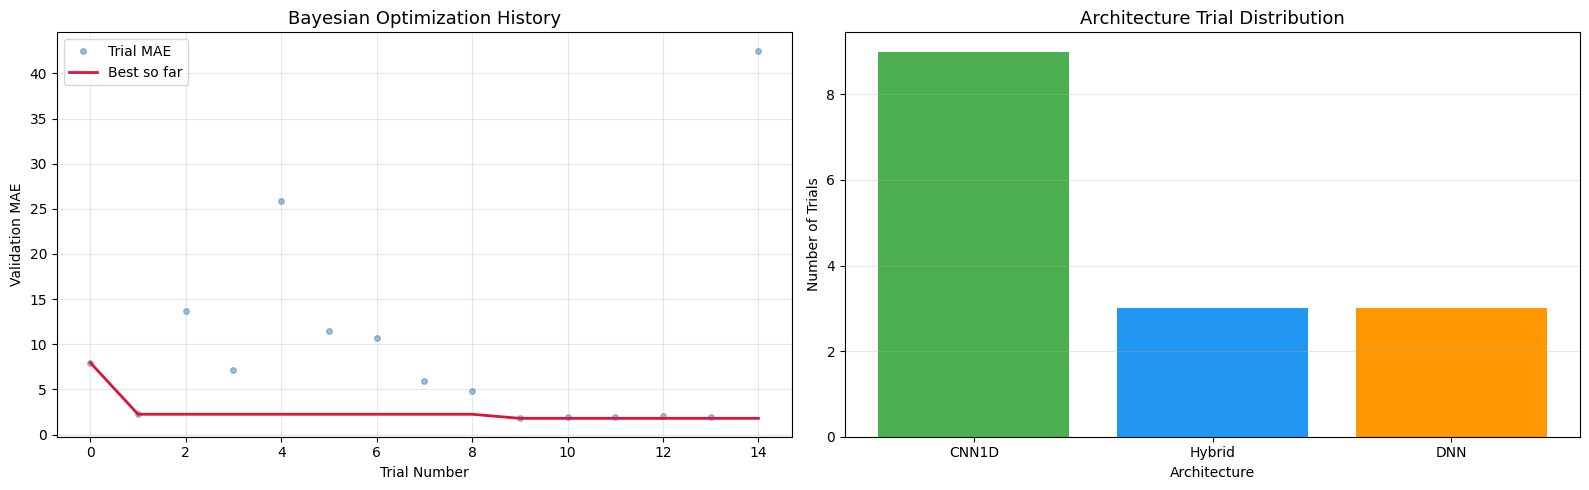

Figure saved: optuna_optimization_history.png


In [13]:
# ── Optuna Visualizations ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Optimization history
trial_vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.minimum.accumulate(trial_vals)
axes[0].plot(trial_vals, 'o', alpha=0.5, markersize=4, label='Trial MAE', color='steelblue')
axes[0].plot(best_so_far, '-', linewidth=2, label='Best so far', color='crimson')
axes[0].set_title('Bayesian Optimization History', fontsize=13)
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Validation MAE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Architecture distribution
arch_counts = {}
for t in study.trials:
    if t.value is not None and 'arch' in t.params:
        a = t.params['arch']
        arch_counts[a] = arch_counts.get(a, 0) + 1
axes[1].bar(arch_counts.keys(), arch_counts.values(), color=['#4CAF50', '#2196F3', '#FF9800'])
axes[1].set_title('Architecture Trial Distribution', fontsize=13)
axes[1].set_xlabel('Architecture')
axes[1].set_ylabel('Number of Trials')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('optuna_optimization_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: optuna_optimization_history.png')

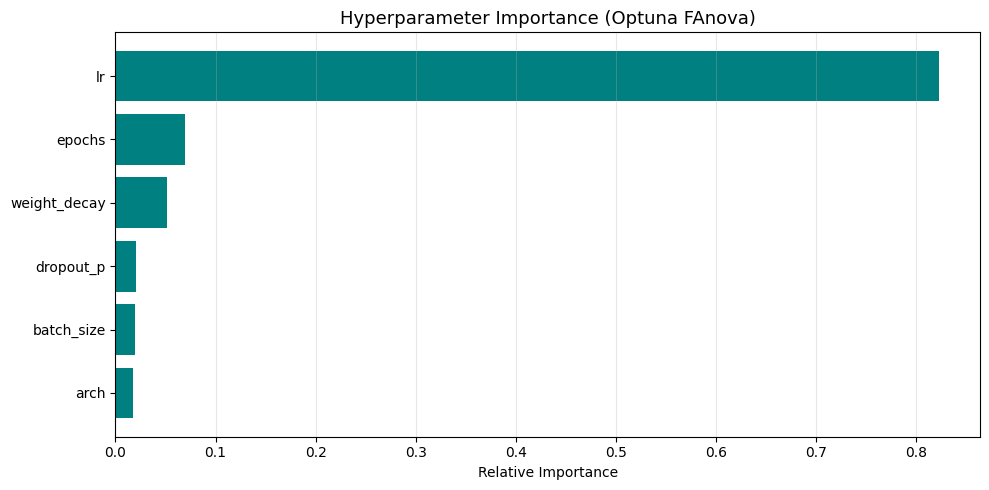

Figure saved: param_importance.png


In [14]:
# ── Parameter Importance (which hyperparameters matter most?) ─────────────────
try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = sorted(importances.items(), key=lambda x: x[1], reverse=True)[:15]

    fig, ax = plt.subplots(figsize=(10, 5))
    names, vals = zip(*params_sorted)
    ax.barh(names[::-1], vals[::-1], color='teal')
    ax.set_title('Hyperparameter Importance (Optuna FAnova)', fontsize=13)
    ax.set_xlabel('Relative Importance')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('param_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved: param_importance.png')
except Exception as e:
    print(f'Importance plot skipped: {e}')

## 9. Retrain Best Model on Full Training Set

In [15]:
# ── Rebuild Best Model from Optuna Params ─────────────────────────────────────
best_params = study.best_params

best_model  = build_model_from_trial(study.best_trial, INPUT_DIM)

best_batch_size = best_params.get('batch_size', 256)
best_epochs     = best_params.get('epochs', 100)
best_lr         = best_params['lr']
best_wd         = best_params['weight_decay']

train_loader, test_loader = make_loaders(
    X_train, y_train, X_test, y_test, batch_size=best_batch_size
)

# Count parameters
total_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
print(f'Best architecture : {best_params.get("arch", "Unknown")}')
print(f'Trainable params  : {total_params:,}')
print(f'Training with lr={best_lr:.5f}, wd={best_wd:.6f}, batch={best_batch_size}, epochs={best_epochs}')
print('\nTraining best model...')

best_model, history = train_model(
    best_model, train_loader, test_loader,
    lr=best_lr, weight_decay=best_wd,
    epochs=best_epochs, patience=20,
    device=DEVICE, verbose=True,
)

Best architecture : CNN1D
Trainable params  : 3,251,713
Training with lr=0.00508, wd=0.000004, batch=64, epochs=26

Training best model...
  Epoch    1/26 | Train Loss: 192.4303 | Val MAE: 27.5506 | Val RMSE: 33.1442 | R²: -1.3766
  Epoch   10/26 | Train Loss: 11.9371 | Val MAE: 2.0816 | Val RMSE: 3.2093 | R²: 0.9777
  Epoch   20/26 | Train Loss: 10.0035 | Val MAE: 1.8746 | Val RMSE: 3.2727 | R²: 0.9768


## 10. Final Evaluation

In [16]:
# ── Compute Final Metrics ──────────────────────────────────────────────────────
mae, rmse, r2, preds, targets = evaluate(best_model, test_loader, DEVICE)

print('\n' + '='*55)
print('       FINAL MODEL PERFORMANCE ON TEST SET')
print('='*55)
print(f'  Mean Absolute Error (MAE) : {mae:.4f}')
print(f'  Root Mean Squared Error   : {rmse:.4f}')
print(f'  R² Score                  : {r2:.4f}')
print('='*55)

# ── Comparison with XGBoost Baseline ──────────────────────────────────────────
print('\n--- Comparison Table ---')
comparison = pd.DataFrame({
    'Model'       : ['XGBoost Baseline', 'XGBoost + Optuna', f'Best NN ({best_params.get("arch","??")}) + Optuna'],
    'MAE'         : [2.8882, 2.5808, mae],
    'RMSE'        : [5.3562, 5.1946, rmse],
    'R²'          : [0.9379, 0.9416, r2],
})
comparison['MAE Improvement vs Baseline'] = ((2.8882 - comparison['MAE']) / 2.8882 * 100).round(1).astype(str) + '%'
print(comparison.to_markdown(index=False))


       FINAL MODEL PERFORMANCE ON TEST SET
  Mean Absolute Error (MAE) : 1.7550
  Root Mean Squared Error   : 3.1959
  R² Score                  : 0.9779

--- Comparison Table ---
| Model                    |     MAE |    RMSE |       R² | MAE Improvement vs Baseline   |
|:-------------------------|--------:|--------:|---------:|:------------------------------|
| XGBoost Baseline         | 2.8882  | 5.3562  | 0.9379   | 0.0%                          |
| XGBoost + Optuna         | 2.5808  | 5.1946  | 0.9416   | 10.6%                         |
| Best NN (CNN1D) + Optuna | 1.75505 | 3.19588 | 0.977903 | 39.2%                         |


## 11. Training Curve & Residuals Analysis

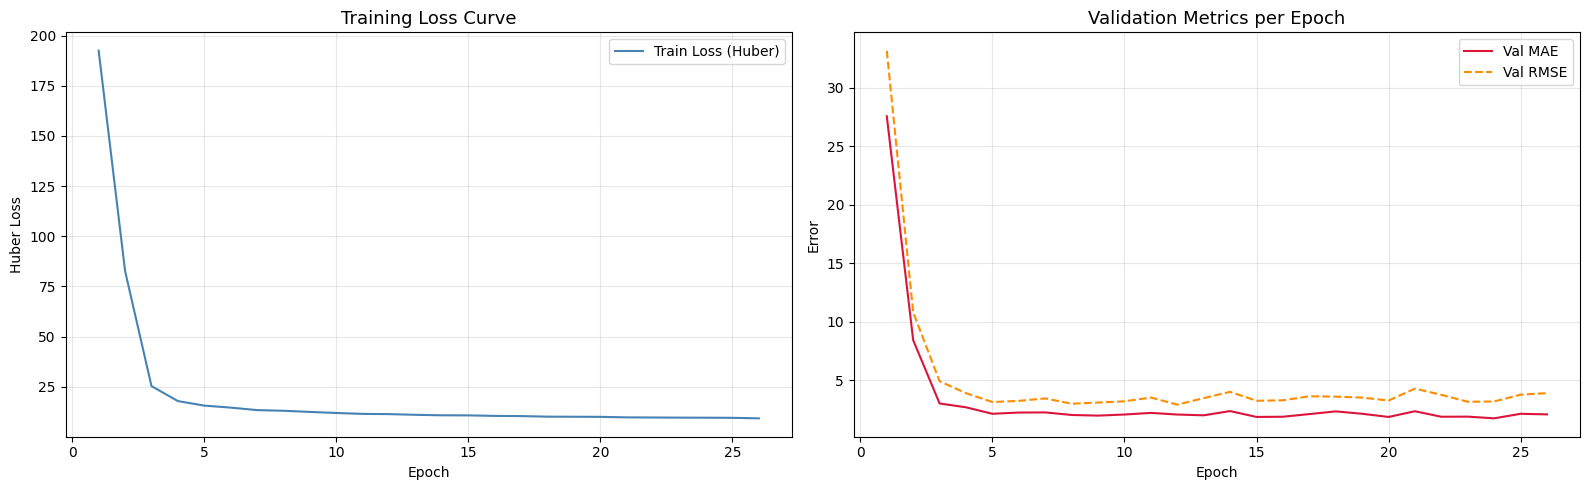

Figure saved: training_curves.png


In [17]:
# ── Training Curve ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss (Huber)', color='steelblue')
axes[0].set_title('Training Loss Curve', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['val_mae'],  label='Val MAE',  color='crimson')
axes[1].plot(epochs_range, history['val_rmse'], label='Val RMSE', color='darkorange', linestyle='--')
axes[1].set_title('Validation Metrics per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: training_curves.png')

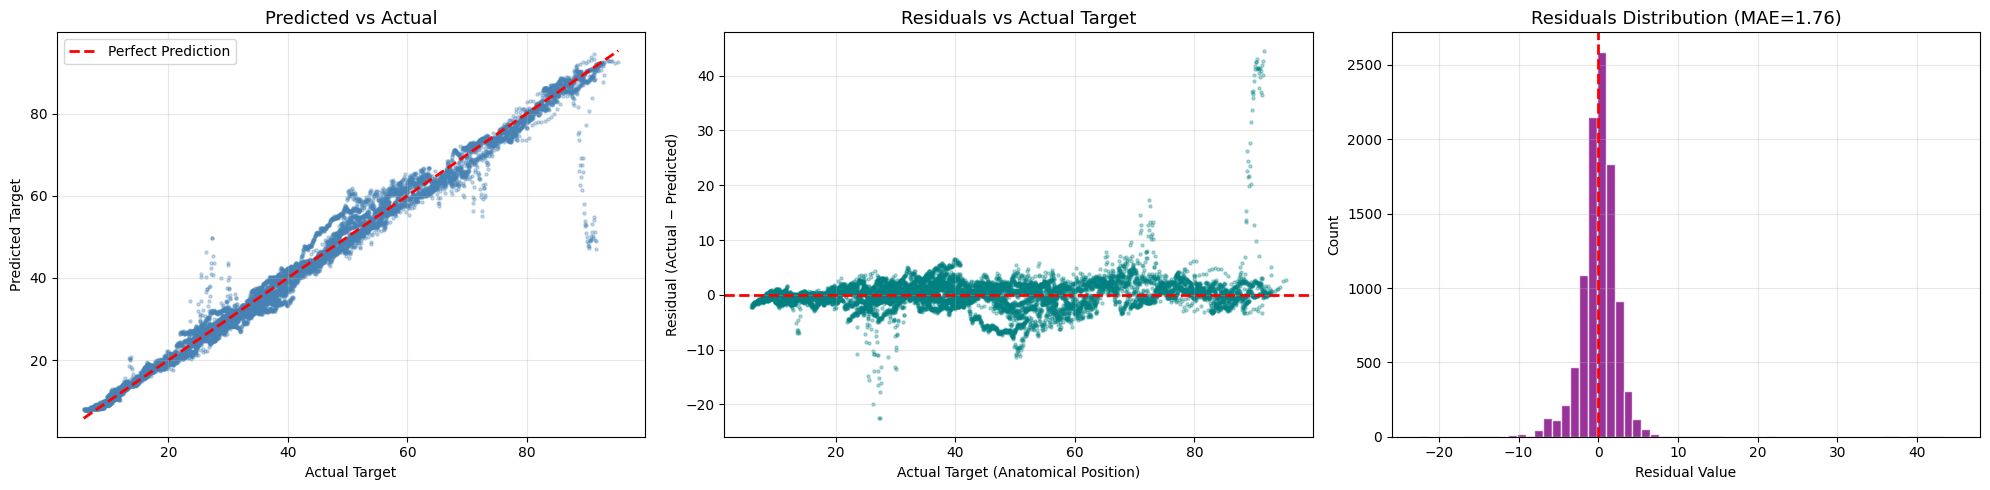

Figure saved: residuals_analysis.png


In [18]:
# ── Residuals Analysis ─────────────────────────────────────────────────────────
residuals = targets - preds

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Predicted vs Actual
axes[0].scatter(targets, preds, alpha=0.3, s=5, color='steelblue')
lo, hi = min(targets.min(), preds.min()), max(targets.max(), preds.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Predicted vs Actual', fontsize=13)
axes[0].set_xlabel('Actual Target')
axes[0].set_ylabel('Predicted Target')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residuals vs Actual (Heteroscedasticity check)
axes[1].scatter(targets, residuals, alpha=0.3, s=5, color='teal')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Actual Target', fontsize=13)
axes[1].set_xlabel('Actual Target (Anatomical Position)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].grid(True, alpha=0.3)

# 3. Residuals Distribution
axes[2].hist(residuals, bins=60, color='purple', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title(f'Residuals Distribution (MAE={mae:.2f})', fontsize=13)
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Count')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: residuals_analysis.png')


--- MAE by Anatomical Zone ---
| zone                     |   Mean MAE |      Std |   Count |
|:-------------------------|-----------:|---------:|--------:|
| 0-20 (Head/Neck)         |   0.754647 | 0.688449 |    1360 |
| 20-40 (Shoulders/Chest)  |   1.52244  | 1.57129  |    3753 |
| 40-60 (Abdomen)          |   2.06301  | 1.8699   |    2732 |
| 60-80 (Pelvis/Upper Leg) |   2.08256  | 1.79029  |    1484 |
| 80-100 (Lower Leg/Feet)  |   2.84286  | 7.3798   |     833 |


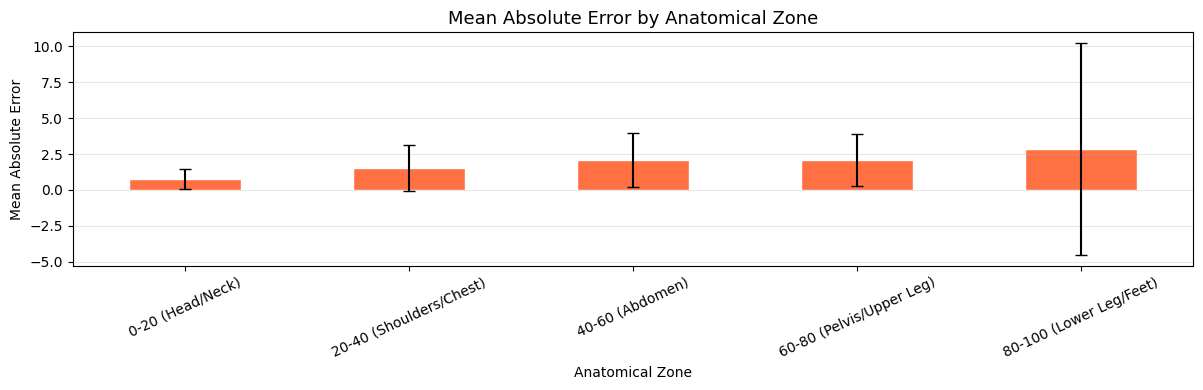

Figure saved: mae_by_zone.png


In [19]:
# ── MAE Breakdown by Anatomical Zone ──────────────────────────────────────────
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20 (Head/Neck)', '20-40 (Shoulders/Chest)', '40-60 (Abdomen)', '60-80 (Pelvis/Upper Leg)', '80-100 (Lower Leg/Feet)']

zone = pd.cut(targets, bins=bins, labels=labels)
zone_mae = pd.DataFrame({'zone': zone, 'abs_err': np.abs(residuals)}).groupby('zone', observed=True)['abs_err'].agg(['mean', 'std', 'count'])
zone_mae.columns = ['Mean MAE', 'Std', 'Count']
print('\n--- MAE by Anatomical Zone ---')
print(zone_mae.to_markdown())

fig, ax = plt.subplots(figsize=(12, 4))
zone_mae['Mean MAE'].plot(kind='bar', ax=ax, color='#FF7043', edgecolor='white')
ax.errorbar(range(len(zone_mae)), zone_mae['Mean MAE'], yerr=zone_mae['Std'], fmt='none', color='black', capsize=4)
ax.set_title('Mean Absolute Error by Anatomical Zone', fontsize=13)
ax.set_xlabel('Anatomical Zone')
ax.set_ylabel('Mean Absolute Error')
ax.tick_params(axis='x', rotation=25)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('mae_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: mae_by_zone.png')

## 12. Save Model

## Architecture Design Rationale

| Design Choice | Reason |
|---|---|
| **GELU activation** | Smoother gradient flow than ReLU; standard in modern deep learning |
| **BatchNorm after each layer** | Stabilizes training on scaled HOG features; reduces sensitivity to learning rate |
| **Huber Loss (δ=5.0)** | Robust to the outlier slices at body extremities (neck, feet) that drive RMSE up |
| **GroupShuffleSplit** | Prevents patient-level data leakage — the single most important preprocessing step |
| **AdaptiveAvgPool1d in CNN** | Makes the model input-length agnostic; aggregates all convolutional channels robustly |
| **OneCycleLR scheduler** | Warm-up + cosine annealing; empirically outperforms StepLR and ReduceLROnPlateau on tabular data |
| **Parallel branches in Hybrid** | DNN captures global correlations across all 289 features; CNN exploits local HOG spatial structure |
| **TPE Bayesian Optimization** | Builds a probabilistic model of the loss surface; 10–50x more efficient than grid/random search |